In [1]:
# Základní importy
import numpy as np
import pandas as pd

# Knihovny, které použiju v budoucnu
from statsmodels.stats.outliers_influence import variance_inflation_factor as VIF
from statsmodels.stats.anova import anova_lm
import statsmodels.api as sm # Pro modely klasické statistiky, inferenci
from matplotlib.pyplot import subplots # grafy

# Pro účely ISLP labs
from ISLP import load_data
from ISLP.models import ModelSpec as MS, summarize, poly

Boston = load_data("Boston")
Boston.columns

# Vytvoření matice pro lineární reresi
# Intercept beta 0 a jeden prediktor lstat
# np.ones vytvoří vektor jedniček délky 506 pro intercept z počtu řádků datasetu .shape[0]
# lstat - procento domácností s nízkým socioekonomickým statusem
# pd.DataFrame skládá sloupce dohromady, výsledkem je matice
# Řádky = pozorování
# Sloupce = paramtery modelu
# Resp. proměnná X představuje souřadnice bodů na ose x
X = pd.DataFrame({"intercept": np.ones(Boston.shape[0]), "lstat": Boston["lstat"]})
X[:4]


,intercept,lstat
0,1.0,4.98
1,1.0,9.14
2,1.0,4.03
3,1.0,2.94


In [3]:
y = Boston["medv"] # závislá proměnná (response)
model = sm.OLS(y, X) # definice modelu; toto není fitování
results = model.fit() # provede OLS fit - regresní přímka
summarize(results) # pouze helper z ISLP knihovny

,coef,std err,t,P>|t|
intercept,34.5538,0.563,61.415,0.0
lstat,-0.9500,0.039,-24.528,0.0


In [4]:
# Toto se v praxi nepoužívá!
design = MS(["lstat"]) # helper z ISLP knihovny - tvorba modelové matice, použít lstat jako prediktor
X = design.fit_transform(Boston) # fot nastuduje dataset; transform vytvoří modelovou matici X pro regresi
X[:4]

,intercept,lstat
0,1.0,4.98
1,1.0,9.14
2,1.0,4.03
3,1.0,2.94


In [5]:
results.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                   medv   R-squared:                       0.544
Model:                            OLS   Adj. R-squared:                  0.543
Method:                 Least Squares   F-statistic:                     601.6
Date:                Tue, 20 Jan 2026   Prob (F-statistic):           5.08e-88
Time:                        20:13:29   Log-Likelihood:                -1641.5
No. Observations:                 506   AIC:                             3287.
Df Residuals:                     504   BIC:                             3295.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
intercept     34.5538      0.563     61.415      0.000      33.448      35.659
lstat         -0.9500      0.039    -24.528      0.000      -1.026      -0.874
==============================================================================
Omnibus:                      137.043   Durbin-Watson:                   0.892
Prob(Omnibus):                  0.000   Jarque-Bera (JB):              291.373
Skew:                           1.453   Prob(JB):                     5.36e-64
Kurtosis:                       5.319   Cond. No.                         29.7
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

In [6]:
new_df = pd.DataFrame({"lstat": [5, 10, 15]})
newX = design.transform(new_df)
newX

,intercept,lstat
0,1.0,5
1,1.0,10
2,1.0,15


In [7]:
new_predictors = results.get_prediction(newX);
new_predictors.predicted_mean

array([29.80359411, 25.05334734, 20.30310057])

In [8]:
new_predictors.conf_int(alpha=0.05)

array([[29.00741194, 30.59977628],
       [24.47413202, 25.63256267],
       [19.73158815, 20.87461299]])

In [9]:
new_predictors.conf_int(obs=True, alpha=0.05)

array([[17.56567478, 42.04151344],
       [12.82762635, 37.27906833],
       [ 8.0777421 , 32.52845905]])

C:\Users\mara2\AppData\Local\Temp\ipykernel_11380\2980895710.py:7: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  abline(ax, results.params[0], results.params[1], "r--", "linewidth=3")


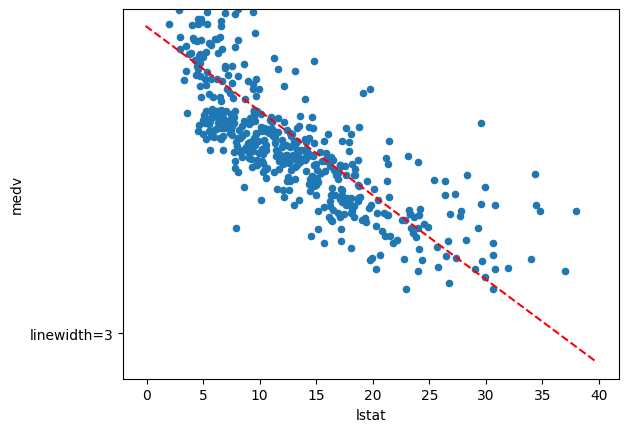

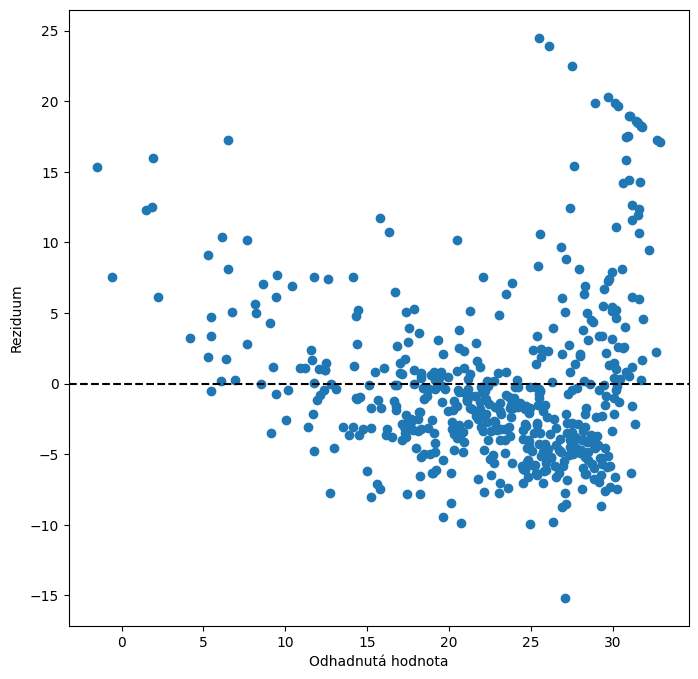

In [10]:
def abline(ax, b, m, *args, **kwargs):
    xlim = ax.get_xlim() # zjistí aktuální rozsah osy x
    ylim = [m * xlim[0] + b, m * xlim[1] + b] # začátek a konec osy y
    ax.plot(xlim, ylim, *args, **kwargs)

ax = Boston.plot.scatter("lstat", "medv")
abline(ax, results.params[0], results.params[1], "r--", "linewidth=3")

ax = subplots(figsize=(8, 8))[1]
ax.scatter(results.fittedvalues, results.resid) # graf reziduí
ax.set_xlabel("Odhadnutá hodnota")
ax.set_ylabel("Reziduum")
ax.axhline(0, c="k", ls="--");

np.int64(374)

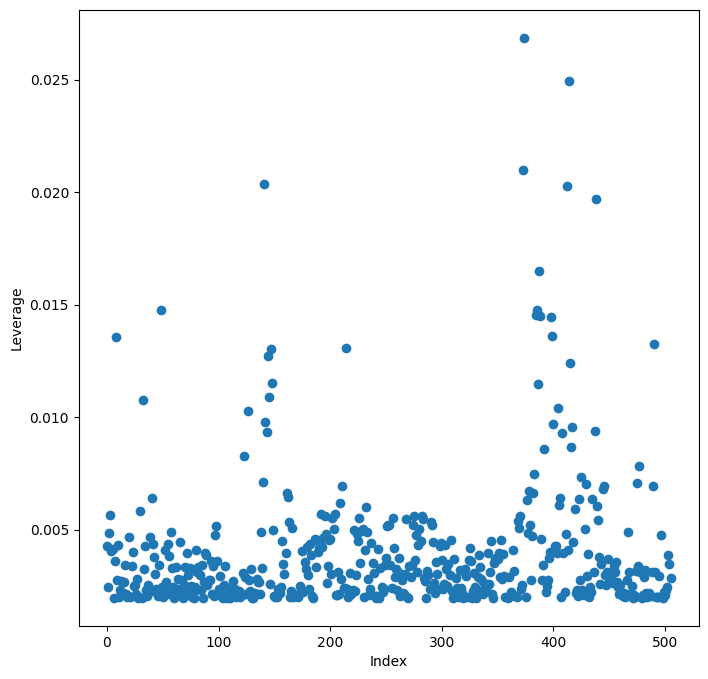

In [11]:
infl = results.get_influence() # pro zjištění outlierů nebo extrémů
ax = subplots(figsize=(8, 8))[1]
ax.scatter(np.arange(X.shape[0]), infl.hat_matrix_diag)
ax.set_xlabel("Index")
ax.set_ylabel("Leverage")
np.argmax(infl.hat_matrix_diag)

In [13]:
X = MS(["lstat", "age"]).fit_transform(Boston)
model1 = sm.OLS(y, X)
results1 = model1.fit()
summarize(results1)

,coef,std err,t,P>|t|
intercept,33.2228,0.731,45.458,0.000
lstat,-1.0321,0.048,-21.416,0.000
age,0.0345,0.012,2.826,0.005


In [16]:
terms = Boston.columns.drop(["medv", "age"])
terms

Index(['crim', 'zn', 'indus', 'chas', 'nox', 'rm', 'dis', 'rad', 'tax',
       'ptratio', 'lstat'],
      dtype='object')

In [ ]:
Xma = MS(terms).fit_transform(Boston)
model = sm.OLS(y, X)
results = model.fit()
summarize(results)

,coef,std err,t,P>|t|
intercept,41.6173,4.936,8.431,0.000
crim,-0.1214,0.033,-3.678,0.000
zn,0.0470,0.014,3.384,0.001
indus,0.0135,0.062,0.217,0.829
chas,2.8400,0.870,3.264,0.001
nox,-18.7580,3.851,-4.870,0.000
rm,3.6581,0.420,8.705,0.000
age,0.0036,0.013,0.271,0.787
dis,-1.4908,0.202,-7.394,0.000
rad,0.2894,0.067,4.325,0.000


In [19]:
np.sqrt(results.scale)

np.float64(4.798034335596367)

In [20]:
vals = [VIF(X, i) for i in range(1, X.shape[1])]
vif = pd.DataFrame({"vif": vals}, index=X.columns[1:])
vif

,vif
crim,1.767486
zn,2.298459
indus,3.987181
chas,1.071168
nox,4.369093
rm,1.912532
age,3.088232
dis,3.954037
rad,7.445301
tax,9.002158


In [21]:
# Interakční člen - jak jeden predikto závisí na hodnotě jiného prediktoru
X = MS(["lstat", "age", ("lstat", "age")]).fit_transform(Boston)
model2 = sm.OLS(y, X)
summarize(model2.fit())

,coef,std err,t,P>|t|
intercept,36.0885,1.470,24.553,0.000
lstat,-1.3921,0.167,-8.313,0.000
age,-0.0007,0.020,-0.036,0.971
lstat:age,0.0042,0.002,2.244,0.025


In [22]:
# Nelineární transformace prediktorů
X = MS([poly("lstat", degree=2), "age"]).fit_transform(Boston)
model3 = sm.OLS(y, X)
results3 = model3.fit()
summarize(results3)

,coef,std err,t,P>|t|
intercept,17.7151,0.781,22.681,0.0
"poly(lstat, degree=2)[0]",-179.2279,6.733,-26.620,0.0
"poly(lstat, degree=2)[1]",72.9908,5.482,13.315,0.0
age,0.0703,0.011,6.471,0.0


In [23]:
# Jestli kvadratická funkce je lepší než lineární
anova_lm(results1, results3)

,df_resid,ssr,df_diff,ss_diff,F,Pr(>F)
0,503.0,19168.128609,0.0,NaN,NaN,NaN
1,502.0,14165.613251,1.0,5002.515357,177.278785,7.468491e-35


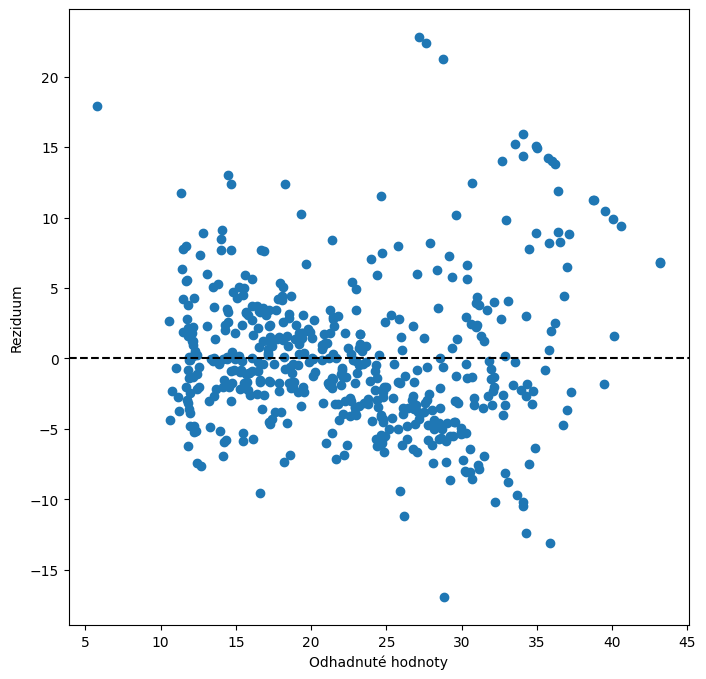

In [24]:
ax = subplots(figsize=(8,8))[1]
ax.scatter(results3.fittedvalues, results3.resid)
ax.set_xlabel("Odhadnuté hodnoty")
ax.set_ylabel("Reziduum")
ax.axhline(0, c="k", ls="--")

In [25]:
Carseats = load_data("Carseats")
Carseats.columns

Index(['Sales', 'CompPrice', 'Income', 'Advertising', 'Population', 'Price',
       'ShelveLoc', 'Age', 'Education', 'Urban', 'US'],
      dtype='object')

In [26]:
allvars = list(Carseats.columns.drop('Sales'))
y = Carseats['Sales']
final = allvars + [('Income', 'Advertising'), ('Price', 'Age')]
X = MS(final).fit_transform(Carseats)
model = sm.OLS(y, X)
summarize(model.fit())

,coef,std err,t,P>|t|
intercept,6.5756,1.009,6.519,0.000
CompPrice,0.0929,0.004,22.567,0.000
Income,0.0109,0.003,4.183,0.000
Advertising,0.0702,0.023,3.107,0.002
Population,0.0002,0.000,0.433,0.665
Price,-0.1008,0.007,-13.549,0.000
ShelveLoc[Good],4.8487,0.153,31.724,0.000
ShelveLoc[Medium],1.9533,0.126,15.531,0.000
Age,-0.0579,0.016,-3.633,0.000
Education,-0.0209,0.020,-1.063,0.288
